# core

> Fill in a module description here

In [1]:
#| default_exp core

In [2]:
#| hide
import sys
import os
sys.path.append("..")

import numpy as np

from CIGNN_experimental.unipen_renderer.parser import Parser
from CIGNN_experimental.unipen_renderer.strokes_to_image_converter import Strokes2ImageConverter

In [3]:
#| export

# Load the pre-processed splines from the numpy file
splines = np.load("../CIGNN_experimental/unipen_renderer/unipen_strokes.npy", allow_pickle=True).item()
splines.keys()


dict_keys([98, 117, 116, 45, 102, 101, 119, 109, 111, 114, 103, 105, 110, 33, 65, 121, 100, 63, 68, 39, 108, 115, 97, 99, 104, 46, 58, 59, 57, 56, 55, 43, 52, 53, 54, 49, 50, 51, 48, 42, 81, 85, 69, 82, 83, 75, 74, 79, 84, 72, 87, 89, 90, 73, 77, 67, 106, 113, 107, 112, 118, 120, 122, 88, 36, 34, 66, 70, 71, 76, 78, 80, 44, 86, 61, 64, 40, 41, 125, 35, 123, 37, 38, 47, 60, 96, 126, 93, 94, 124, 62, 91, 92, 95])

In [4]:
[f"{i} {len(splines[80][i])}" for i in list(range(10))]  # Find a sample with more than one trajectory

['0 1', '1 1', '2 2', '3 1', '4 1', '5 2', '6 2', '7 1', '8 2', '9 2']

In [5]:
splines[80][7][0]

[[(1184, 701),
  (1183, 700),
  (1181, 698),
  (1179, 695),
  (1177, 692),
  (1174, 676),
  (1172, 671),
  (1170, 667),
  (1169, 664),
  (1166, 660),
  (1164, 659),
  (1162, 660),
  (1161, 663),
  (1162, 667),
  (1164, 674),
  (1169, 685),
  (1176, 695),
  (1184, 704),
  (1193, 712),
  (1200, 717),
  (1206, 718),
  (1212, 718),
  (1216, 717),
  (1218, 715),
  (1216, 711),
  (1213, 707),
  (1208, 703),
  (1200, 699),
  (1192, 696),
  (1184, 693),
  (1178, 693)]]

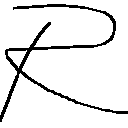

In [30]:
s2i = Strokes2ImageConverter()
s2i.strokes_to_image(strokes=splines[80][0])

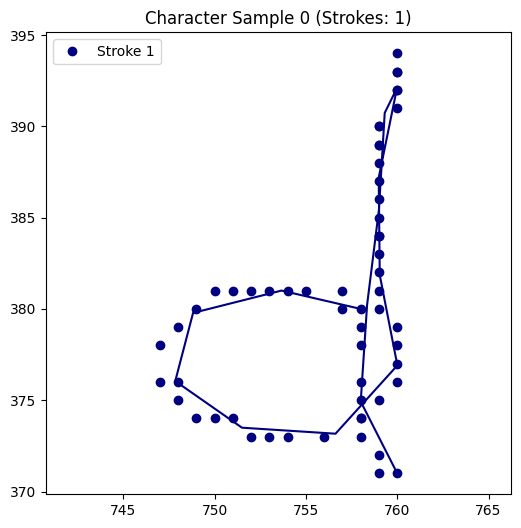

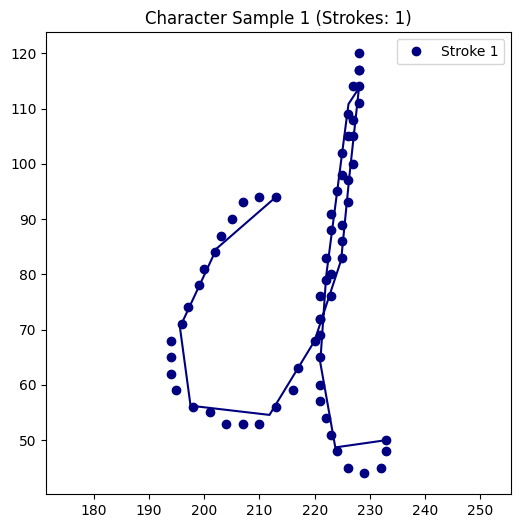

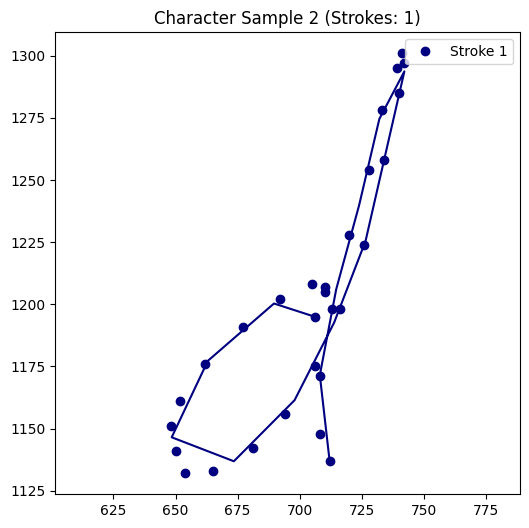

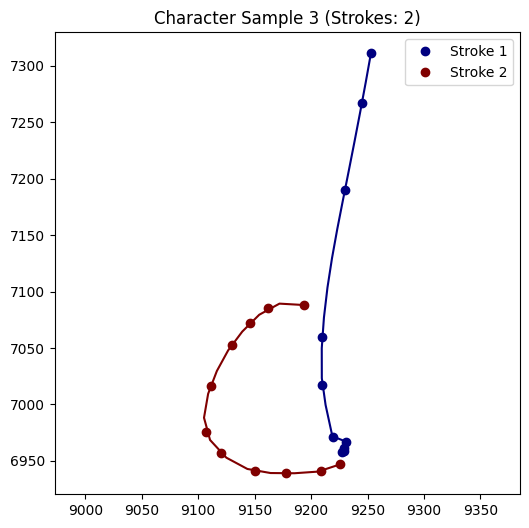

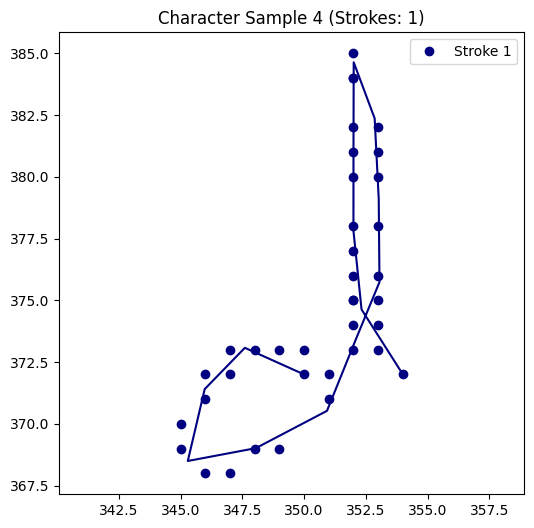

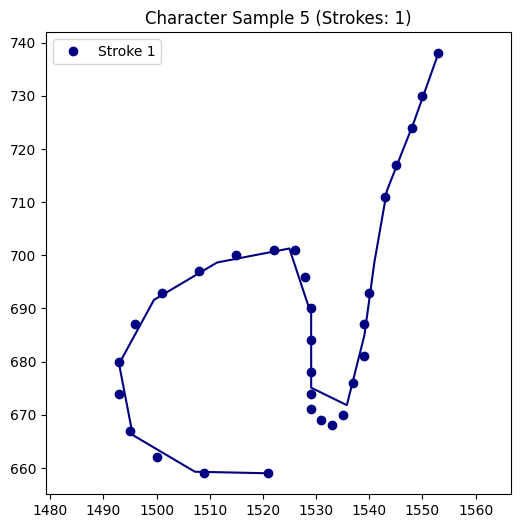

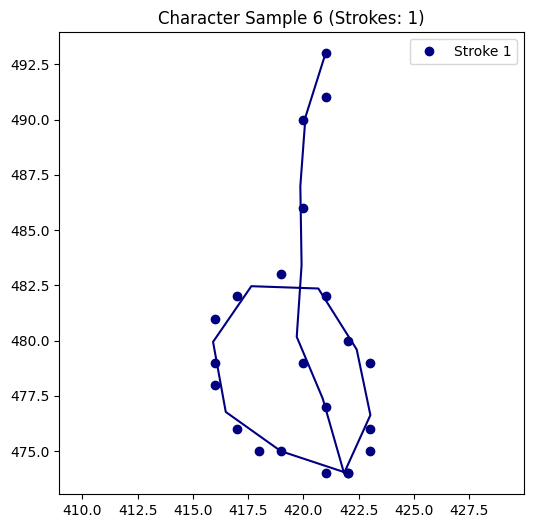

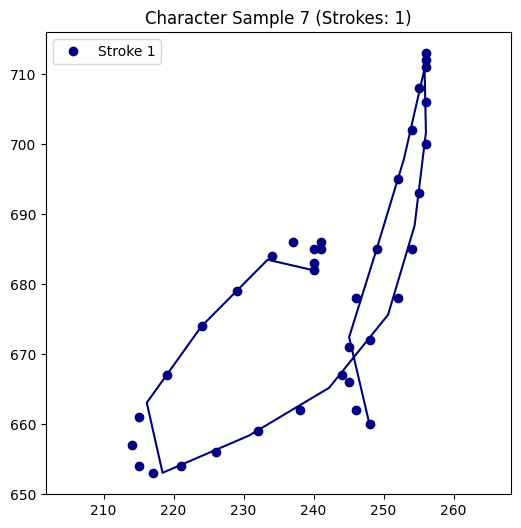

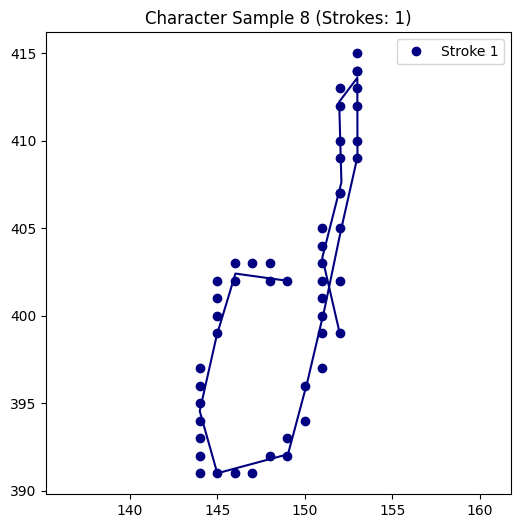

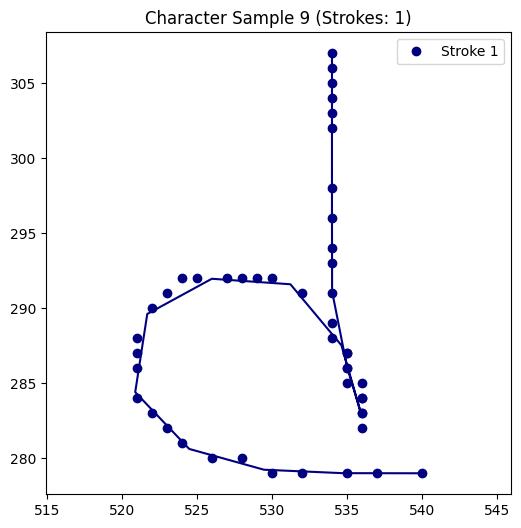

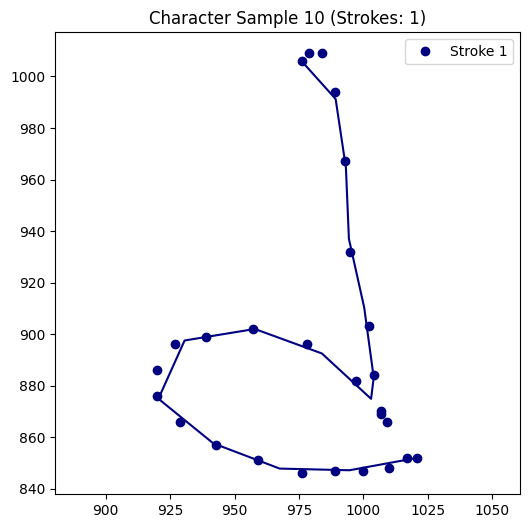

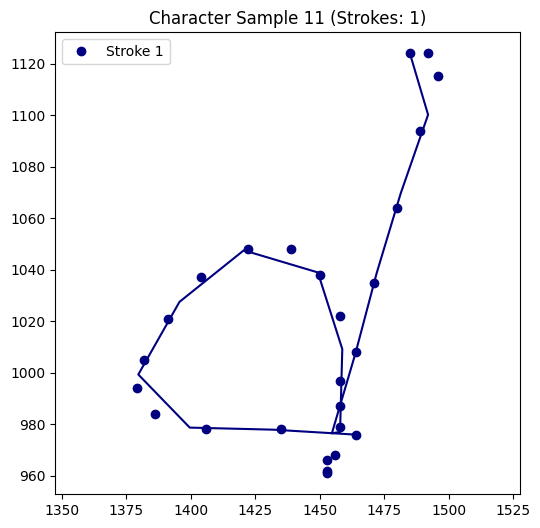

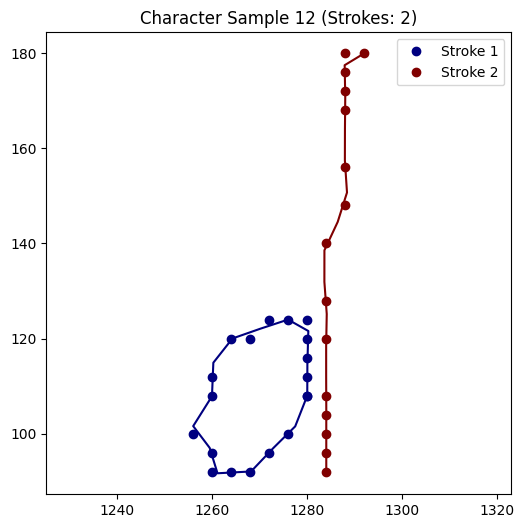

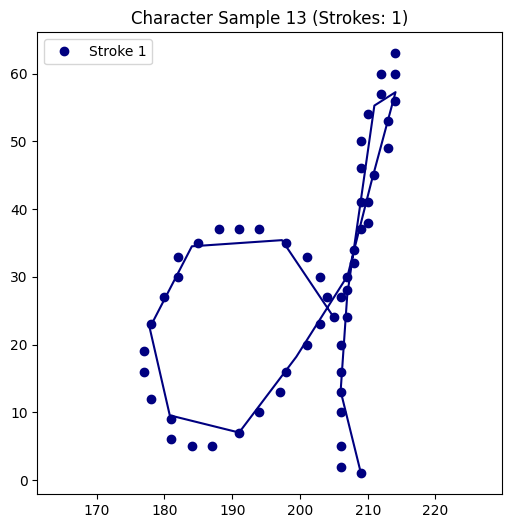

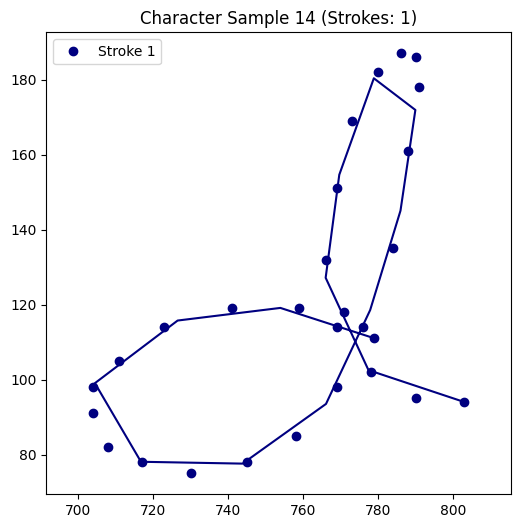

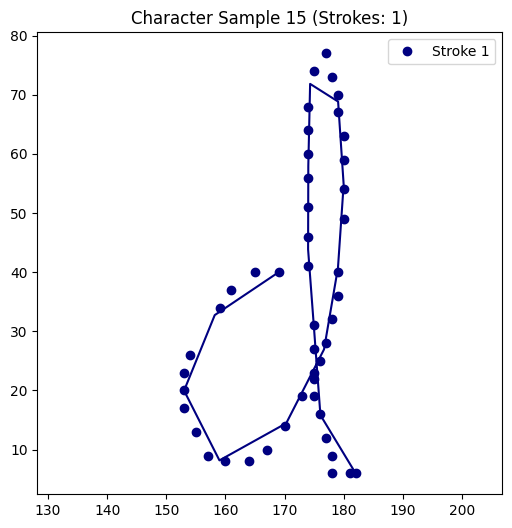

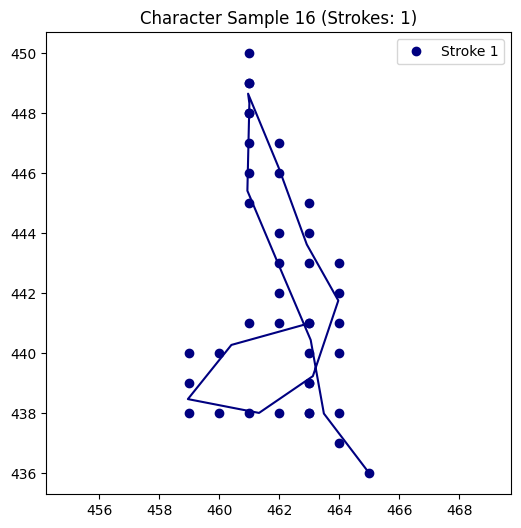

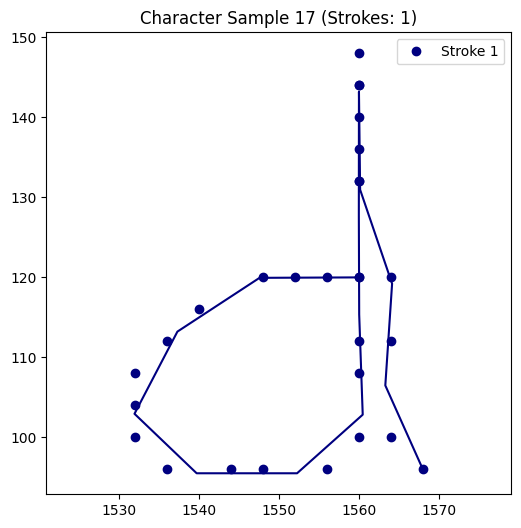

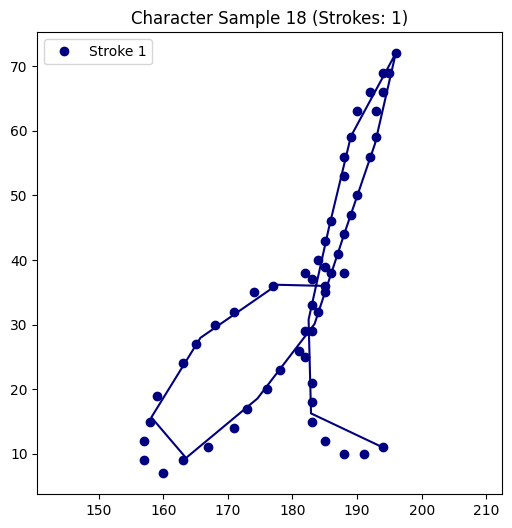

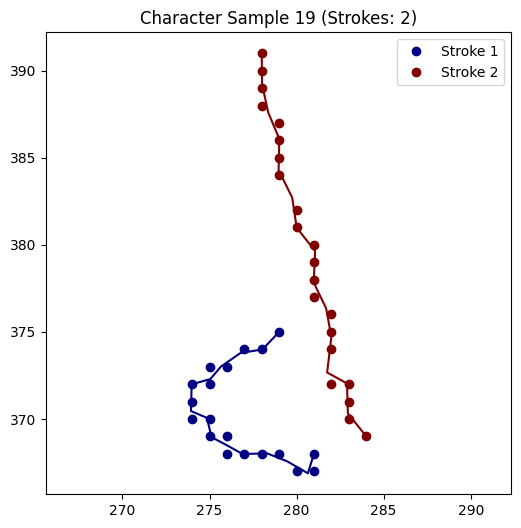

In [46]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import CubicSpline

char = splines[100]
smoothness = 15

for i in range(20):
    idx = np.random.randint(len(char))
    
    strokes = len(char[idx])
    if strokes == 0:
        print(f"No strokes found for index {idx}")
        continue

    plt.figure(figsize=(6, 6))
    colors = plt.cm.jet(np.linspace(0, 1, strokes))  # Generate distinct colors for strokes

    for stroke in range(strokes):
        
        spline = char[idx][stroke]
        points = np.array(spline)

        x = points[:, 0]
        y = points[:, 1]
        
        # Create parameter t based on cumulative distance along the path
        dx = np.diff(x)
        dy = np.diff(y)
        dist = np.sqrt(dx * dx + dy * dy)
        dist = np.insert(dist, 0, 0)  # insert 0 at the beginning
        t = np.cumsum(dist)
        
        # Remove duplicate t values to satisfy the CubicSpline requirement
        t, unique_idx = np.unique(t, return_index=True)
        x = x[unique_idx]
        y = y[unique_idx]

        # Fit cubic splines to x(t) and y(t)
        cs_x = CubicSpline(t, x)
        cs_y = CubicSpline(t, y)

        # Generate points for a smooth curve
        t_smooth = np.linspace(0, t[-1], smoothness)
        x_smooth = cs_x(t_smooth)
        y_smooth = cs_y(t_smooth)

        # Plot original points and smooth curve with unique color for each stroke
        plt.plot(x, y, 'o', color=colors[stroke], label=f'Stroke {stroke + 1}')
        plt.plot(x_smooth, y_smooth, '-', color=colors[stroke])

    plt.title(f"Character Sample {i} (Strokes: {strokes})")
    plt.legend()
    plt.axis('equal')  # Maintain aspect ratio
    plt.show()


In [32]:
#| hide
import nbdev; nbdev.nbdev_export()

ModuleNotFoundError: No module named 'nbdev'